<a href="https://colab.research.google.com/github/raaghavkk/UG04-NLP-COMM061/blob/main/notebooks/raaghav_crossvariety_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q2.2 — Inner Circle vs Outer Circle Evaluation
**RoBERTa trained on pooled en-UK + en-AU (Inner Circle) vs en-IN (Outer Circle) — Sarcasm Task**

In [1]:
!pip install transformers datasets torch scikit-learn

In [2]:
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import RobertaTokenizer, RobertaForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-40GB


In [4]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("surrey-nlp/BESSTIE-CW-26")

df_train = pd.DataFrame(ds['train'])
df_test = pd.DataFrame(ds['test'])

# Split by variety
train_au = df_train[df_train['variety'] == 'en-AU'].reset_index(drop=True)
train_in = df_train[df_train['variety'] == 'en-IN'].reset_index(drop=True)
train_uk = df_train[df_train['variety'] == 'en-UK'].reset_index(drop=True)

test_au = df_test[df_test['variety'] == 'en-AU'].reset_index(drop=True)
test_in = df_test[df_test['variety'] == 'en-IN'].reset_index(drop=True)
test_uk = df_test[df_test['variety'] == 'en-UK'].reset_index(drop=True)

print("Train sizes:", len(train_au), len(train_in), len(train_uk))
print("Test sizes:", len(test_au), len(test_in), len(test_uk))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

Train sizes: 1145 1399 1203
Test sizes: 667 816 700


In [5]:
# Pool inner circle varieties
df_inner = pd.concat([train_au, train_uk]).reset_index(drop=True)
print(f"Inner circle pooled size: {len(df_inner)}")
print(f"en-IN train size: {len(train_in)}")
print(f"en-IN test size: {len(test_in)}")

Inner circle pooled size: 2348
en-IN train size: 1399
en-IN test size: 816


In [6]:
from sklearn.utils import resample

# Separate sarcastic and non-sarcastic in en-IN training set
in_sarcastic = train_in[train_in['Sarcasm'] == 1]
in_not_sarcastic = train_in[train_in['Sarcasm'] == 0]

print(f"Before balancing — Not Sarcastic: {len(in_not_sarcastic)}, Sarcastic: {len(in_sarcastic)}")

# Oversample sarcastic to match non-sarcastic count
in_sarcastic_oversampled = resample(in_sarcastic,
                                     replace=True,
                                     n_samples=len(in_not_sarcastic),
                                     random_state=42)

train_in_balanced = pd.concat([in_not_sarcastic, in_sarcastic_oversampled]).reset_index(drop=True)
train_in_balanced = train_in_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"After balancing — Not Sarcastic: {len(train_in_balanced[train_in_balanced['Sarcasm']==0])}, Sarcastic: {len(train_in_balanced[train_in_balanced['Sarcasm']==1])}")
print(f"Total training size: {len(train_in_balanced)}")

Before balancing — Not Sarcastic: 1304, Sarcastic: 95
After balancing — Not Sarcastic: 1304, Sarcastic: 1304
Total training size: 2608


In [7]:
from transformers import RobertaTokenizer
from torch.utils.data import Dataset
import torch

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

class SarcasmDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['text'].tolist()
        self.labels = df['Sarcasm'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Tokenizer and dataset class ready")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer and dataset class ready


In [8]:
from transformers import RobertaForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'macro_f1': f1_score(labels, predictions, average='macro'),
        'precision': precision_score(labels, predictions, average='macro', zero_division=0),
        'recall': recall_score(labels, predictions, average='macro', zero_division=0)
    }

def train_roberta(train_df, variety_name, seed=42):
    print(f"\nTraining on {variety_name} (seed={seed})...")

    torch.manual_seed(seed)
    np.random.seed(seed)

    model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
    train_dataset = SarcasmDataset(train_df, tokenizer)

    training_args = TrainingArguments(
        output_dir=f'./results_{variety_name}_seed{seed}',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=50,
        save_strategy='no',
        report_to='none',
        seed=seed
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    print(f"Training on {variety_name} (seed={seed}) complete!")
    return trainer, model

In [9]:
def evaluate_model(trainer, test_df, model):
    test_dataset = SarcasmDataset(test_df, tokenizer)
    predictions = trainer.predict(test_dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = test_df['Sarcasm'].astype(int).tolist()

    return {
        'macro_f1': f1_score(labels, preds, average='macro'),
        'precision': precision_score(labels, preds, average='macro', zero_division=0),
        'recall': recall_score(labels, preds, average='macro', zero_division=0)
    }


In [10]:
# Seed 42 runs
trainer_au, model_au = train_roberta(train_au, 'en-AU', seed=42)
trainer_in, model_in = train_roberta(train_in, 'en-IN', seed=42)
trainer_in_bal, model_in_bal = train_roberta(train_in_balanced, 'en-IN-balanced', seed=42)  # balanced one (just for testinf)
trainer_uk, model_uk = train_roberta(train_uk, 'en-UK', seed=42)
trainer_inner, model_inner = train_roberta(df_inner, 'inner_circle', seed=42)


Training on en-AU (seed=42)...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Training on en-UK (seed=42) complete!

Training on inner_circle (seed=42)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.529506
100,0.417189
150,0.379737
200,0.384388
250,0.386536
300,0.329675
350,0.298244
400,0.281759


Training on inner_circle (seed=42) complete!


In [11]:
# Seed 123 runs
trainer_au2, model_au2 = train_roberta(train_au, 'en-AU', seed=123)
trainer_in2, model_in2 = train_roberta(train_in, 'en-IN', seed=123)
trainer_in_bal2, model_in_bal2 = train_roberta(train_in_balanced, 'en-IN-balanced', seed=123)  #addedtstocehck?lol
trainer_uk2, model_uk2 = train_roberta(train_uk, 'en-UK', seed=123)
trainer_inner2, model_inner2 = train_roberta(df_inner, 'inner_circle', seed=123)


Training on en-AU (seed=123)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.626399
100,0.454545
150,0.517274
200,0.405552


Training on en-AU (seed=123) complete!

Training on en-IN (seed=123)...


...

Training on en-UK (seed=123) complete!

Training on inner_circle (seed=123)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.566313
100,0.431232
150,0.371824
200,0.340556
250,0.375342
300,0.382257
350,0.327162
400,0.254513


Training on inner_circle (seed=123) complete!


In [12]:
# Build the 3x3 matrix
varieties = ['en-AU', 'en-IN', 'en-UK']
trainers = [trainer_au, trainer_in, trainer_uk]
models = [model_au, model_in, model_uk]
test_sets = [test_au, test_in, test_uk]

results = {}
for i, (train_variety, trainer, model) in enumerate(zip(varieties, trainers, models)):
    results[train_variety] = {}
    for j, test_variety in enumerate(varieties):
        print(f"Evaluating: trained on {train_variety}, testing on {test_variety}...")
        results[train_variety][test_variety] = evaluate_model(trainer, test_sets[j], model)

print("\nDone!")

Evaluating: trained on en-AU, testing on en-AU...


Evaluating: trained on en-AU, testing on en-IN...


Evaluating: trained on en-AU, testing on en-UK...


Evaluating: trained on en-IN, testing on en-AU...


Evaluating: trained on en-IN, testing on en-IN...


Evaluating: trained on en-IN, testing on en-UK...


Evaluating: trained on en-UK, testing on en-AU...


Evaluating: trained on en-UK, testing on en-IN...


Evaluating: trained on en-UK, testing on en-UK...



Done!


In [13]:
print("=== Q2.2 RESULTS (averaged over 2 runs) ===\n")

inner_r1 = evaluate_model(trainer_inner, test_in, model_inner)
inner_r2 = evaluate_model(trainer_inner2, test_in, model_inner2)

in_r1 = evaluate_model(trainer_in, test_in, model_in)
in_r2 = evaluate_model(trainer_in2, test_in, model_in2)

in_bal_r1 = evaluate_model(trainer_in_bal, test_in, model_in_bal)
in_bal_r2 = evaluate_model(trainer_in_bal2, test_in, model_in_bal2)

print(f"Inner Circle (en-AU + en-UK) → Test en-IN:")
print(f"  Run 1: {inner_r1['macro_f1']:.4f} | Run 2: {inner_r2['macro_f1']:.4f} | Avg: {(inner_r1['macro_f1'] + inner_r2['macro_f1'])/2:.4f}")

print(f"\nen-IN only (imbalanced) → Test en-IN:")
print(f"  Run 1: {in_r1['macro_f1']:.4f} | Run 2: {in_r2['macro_f1']:.4f} | Avg: {(in_r1['macro_f1'] + in_r2['macro_f1'])/2:.4f}")

print(f"\nen-IN balanced (oversampled) → Test en-IN:")
print(f"  Run 1: {in_bal_r1['macro_f1']:.4f} | Run 2: {in_bal_r2['macro_f1']:.4f} | Avg: {(in_bal_r1['macro_f1'] + in_bal_r2['macro_f1'])/2:.4f}")

=== Q2.2 RESULTS (averaged over 2 runs) ===



Inner Circle (en-AU + en-UK) → Test en-IN:
  Run 1: 0.6023 | Run 2: 0.5745 | Avg: 0.5884

en-IN only (imbalanced) → Test en-IN:
  Run 1: 0.4822 | Run 2: 0.4822 | Avg: 0.4822

en-IN balanced (oversampled) → Test en-IN:
  Run 1: 0.4799 | Run 2: 0.5579 | Avg: 0.5189


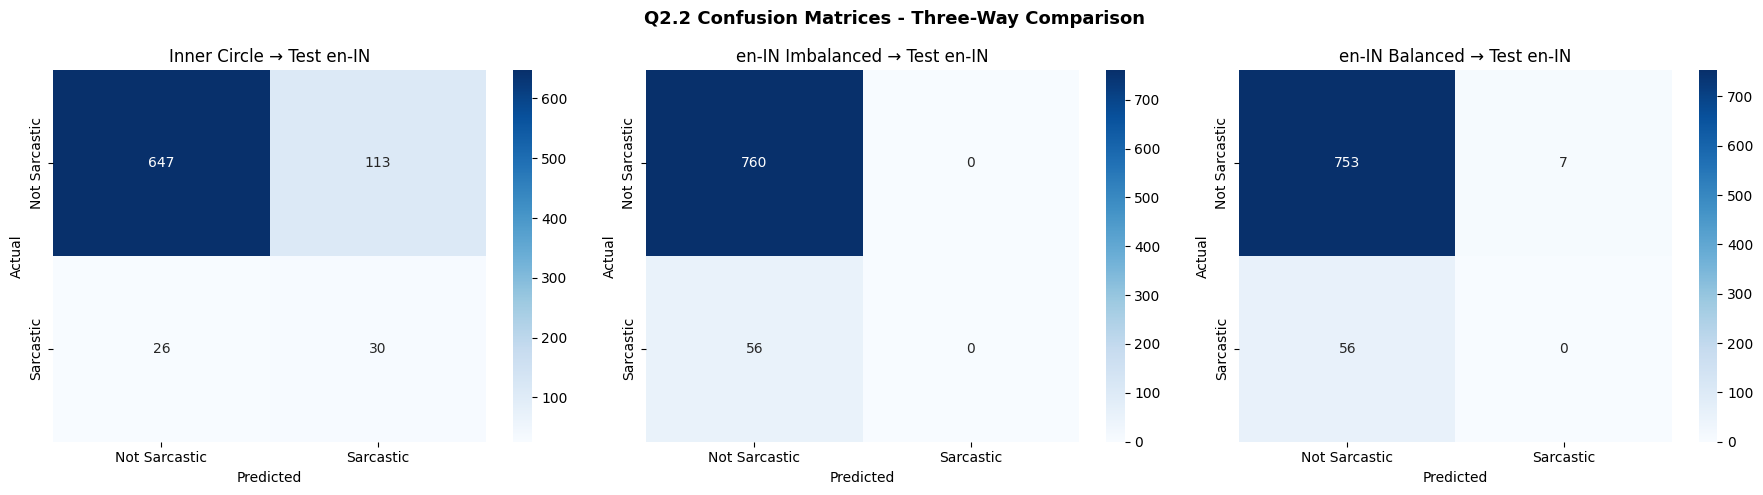

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Inner circle
test_dataset = SarcasmDataset(test_in, tokenizer)
preds_inner = np.argmax(trainer_inner.predict(test_dataset).predictions, axis=-1)
labels_in = test_in['Sarcasm'].astype(int).tolist()

cm_inner = confusion_matrix(labels_in, preds_inner)
sns.heatmap(cm_inner, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Sarcastic', 'Sarcastic'],
            yticklabels=['Not Sarcastic', 'Sarcastic'])
axes[0].set_title('Inner Circle → Test en-IN')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# en-IN imbalanced
preds_in = np.argmax(trainer_in.predict(test_dataset).predictions, axis=-1)
cm_in = confusion_matrix(labels_in, preds_in)
sns.heatmap(cm_in, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Sarcastic', 'Sarcastic'],
            yticklabels=['Not Sarcastic', 'Sarcastic'])
axes[1].set_title('en-IN Imbalanced → Test en-IN')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# en-IN balanced
preds_in_bal = np.argmax(trainer_in_bal.predict(test_dataset).predictions, axis=-1)
cm_in_bal = confusion_matrix(labels_in, preds_in_bal)
sns.heatmap(cm_in_bal, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Not Sarcastic', 'Sarcastic'],
            yticklabels=['Not Sarcastic', 'Sarcastic'])
axes[2].set_title('en-IN Balanced → Test en-IN')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Q2.2 Confusion Matrices - Three-Way Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q22_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Additional Analysis — Full Cross-Variety Matrix
*The following 3x3 evaluation matrix provides extended analysis beyond the core Q2.2 requirement.*


=== CROSS-VARIETY EVALUATION MATRIX (Macro-F1) ===

            Test:en-AU   Test:en-IN   Test:en-UK   
Train:en-AU   0.7480      0.5480      0.6441      
Train:en-IN   0.4139      0.4822      0.4803      
Train:en-UK   0.4139      0.4822      0.4803      


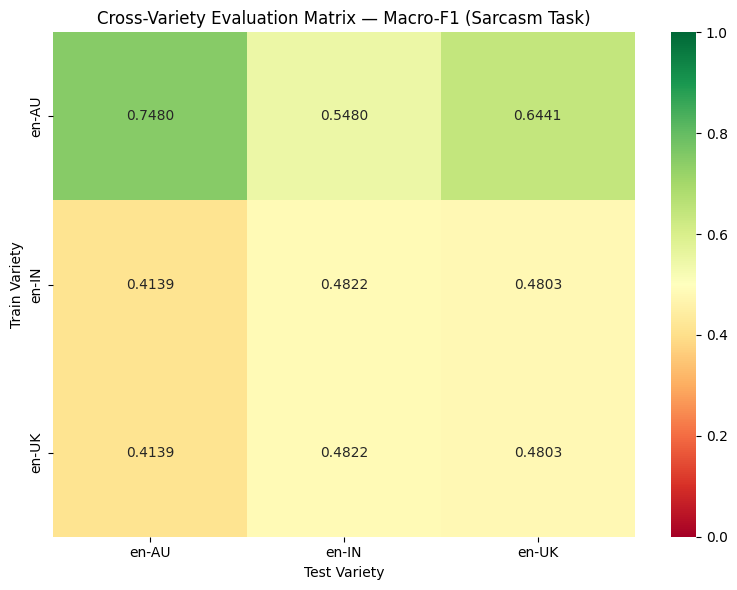

In [15]:
# Print results table
print("\n=== CROSS-VARIETY EVALUATION MATRIX (Macro-F1) ===\n")
print(f"{'':12}", end="")
for v in varieties:
    print(f"Test:{v:8}", end="")
print()

for train_v in varieties:
    print(f"Train:{train_v:8}", end="")
    for test_v in varieties:
        print(f"{results[train_v][test_v]['macro_f1']:.4f}      ", end="")
    print()

# Build F1 matrix for heatmap
f1_matrix = np.array([[results[tv][ev]['macro_f1'] for ev in varieties] for tv in varieties])

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(f1_matrix, annot=True, fmt='.4f', xticklabels=varieties, yticklabels=varieties,
            cmap='RdYlGn', vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Test Variety')
ax.set_ylabel('Train Variety')
ax.set_title('Cross-Variety Evaluation Matrix — Macro-F1 (Sarcasm Task)')
plt.tight_layout()
plt.savefig('crossvariety_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Balanced en-IN model tested on all three varieties
print("=== BALANCED en-IN MODEL — Cross-Variety Results ===\n")

bal_results = {}
for test_variety, test_set in zip(['en-AU', 'en-IN', 'en-UK'], [test_au, test_in, test_uk]):
    r = evaluate_model(trainer_in_bal, test_set, model_in_bal)
    bal_results[test_variety] = r
    print(f"Balanced en-IN → Test {test_variety}:")
    print(f"  Macro-F1: {r['macro_f1']:.4f} | Precision: {r['precision']:.4f} | Recall: {r['recall']:.4f}")

=== BALANCED en-IN MODEL — Cross-Variety Results ===



Balanced en-IN → Test en-AU:
  Macro-F1: 0.4431 | Precision: 0.6554 | Recall: 0.5111


Balanced en-IN → Test en-IN:
  Macro-F1: 0.4799 | Precision: 0.4654 | Recall: 0.4954


Balanced en-IN → Test en-UK:
  Macro-F1: 0.5473 | Precision: 0.7504 | Recall: 0.5354


In [16]:
print("\n=== FULL RESULTS TABLE ===\n")
print(f"{'Train':<8} {'Test':<8} {'Macro-F1':<12} {'Precision':<12} {'Recall':<12}")
print("-" * 52)
for train_v in varieties:
    for test_v in varieties:
        r = results[train_v][test_v]
        print(f"{train_v:<8} {test_v:<8} {r['macro_f1']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f}")


=== FULL RESULTS TABLE ===

Train    Test     Macro-F1     Precision    Recall      
----------------------------------------------------
en-AU    en-AU    0.7480       0.7666       0.7362      
en-AU    en-IN    0.5480       0.5631       0.7014      
en-AU    en-UK    0.6441       0.6233       0.8200      
en-IN    en-AU    0.4139       0.3531       0.5000      
en-IN    en-IN    0.4822       0.4657       0.5000      
en-IN    en-UK    0.4803       0.4621       0.5000      
en-UK    en-AU    0.4139       0.3531       0.5000      
en-UK    en-IN    0.4822       0.4657       0.5000      
en-UK    en-UK    0.4803       0.4621       0.5000      


In [17]:
from sklearn.metrics import classification_report

print("=== PER-CLASS RESULTS — Inner Circle → en-IN ===\n")
test_dataset = SarcasmDataset(test_in, tokenizer)
preds_inner = np.argmax(trainer_inner.predict(test_dataset).predictions, axis=-1)
labels_in = test_in['Sarcasm'].astype(int).tolist()

print(classification_report(labels_in, preds_inner,
      target_names=['Not Sarcastic', 'Sarcastic']))

print("=== PER-CLASS RESULTS — en-IN only → en-IN ===\n")
preds_in_only = np.argmax(trainer_in.predict(test_dataset).predictions, axis=-1)

print(classification_report(labels_in, preds_in_only,
      target_names=['Not Sarcastic', 'Sarcastic']))

=== PER-CLASS RESULTS — Inner Circle → en-IN ===



               precision    recall  f1-score   support

Not Sarcastic       0.96      0.85      0.90       760
    Sarcastic       0.21      0.54      0.30        56

     accuracy                           0.83       816
    macro avg       0.59      0.69      0.60       816
 weighted avg       0.91      0.83      0.86       816

=== PER-CLASS RESULTS — en-IN only → en-IN ===



               precision    recall  f1-score   support

Not Sarcastic       0.93      1.00      0.96       760
    Sarcastic       0.00      0.00      0.00        56

     accuracy                           0.93       816
    macro avg       0.47      0.50      0.48       816
 weighted avg       0.87      0.93      0.90       816



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Q2.2 Key Findings

The core question here wad whether pooling the two inner circle varieties together
would help a model generalise to Indian English better than a model trained on Indian
English itself. We extended this to a three-way comparison by also training a balanced
version of the en-IN model using oversampling to address the 13:1 class imbalance.

The inner circle model (en-AU + en-UK combined) averages 0.5884 Macro-F1 on en-IN
across both runs and is the clear winner. The confusion matrix shows it correctly identifying 30 sarcastic instances but also
generating 113 false positives, meaning it's over-predicting sarcasm and incorrectly
flagging a lot of non-sarcastic content. It's casting too wide a net but at least
it's attempting to detect sarcasm, which is more than the other two models manage.

The imbalanced en-IN model scores 0.4822 and predicts literally zero sarcastic instances
across both runs. The confusion matrix is just a wall of not sarcastic. The model never
saw enough sarcastic examples during training to learn what Indian English sarcasm even
looks like so it just defaulted to the majority class every single time.

The balanced en-IN model does slightly better at 0.5189 average but still predicts
zero sarcastic instances correctly. The confusion matrix shows 7 false positives where
it incorrectly flagged non-sarcastic content as sarcastic, and 56 actual sarcastic
instances completely missed. The oversampling technically improved the Macro-F1 slightly
but looking at the confusion matrix the model is still basically useless at detecting
Indian English sarcasm, it just occasionally guesses wrong in the opposite direction now.

This is where it gets interesting though. Even after perfectly balancing the training
data, the en-IN model still can't detect sarcasm properly. And that's because the
problem isn't really about data balance at all, it's about how culturally distinct
Indian English sarcasm actually is.

Indian English isn't one thing. Someone from Chennai, someone from Delhi, and someone
from Kolkata all speak English differently, use different slang, and express sarcasm
in completely different ways. A model trained on a mix of Indian English Reddit comments
is trying to generalise across something that doesn't have a single consistent pattern
to learn from. British and Australian English are much more regionally uniform in
comparison, which is part of why the inner circle model actually works.

On top of that, Indian English sarcasm often lives in the space between Hindi and
English in a way that has no equivalent in other varieties. Code-mixing is so deeply
embedded in how Indian English speakers communicate, especially on Reddit, that a lot
of the sarcastic intent is carried by Hindi words and phonetic substitutions that
RoBERTa has zero framework for. We showed in Q1 that terms like "batakh" get
fragmented into meaningless tokens entirely, so the model can't even read the word
let alone understand the cultural joke behind it. Balancing the dataset doesn't fix
any of that, it just gives the model more copies of examples it already couldn't
understand.

The inner circle model works better not because it knows Indian English, but because
it was trained on more balanced data from varieties where the sarcasm signal is cleaner
and more consistent. It's essentially learning a general pattern of what sarcasm looks
like in English and applying that pattern to Indian English, which works just enough
to beat a model that was trained on the actual target variety but couldn't learn
anything from it.

### Connection to Q1

These results make a lot more sense when you read them alongside the Q1 findings. The
word cloud and tokenization analysis showed like how differently Indian English vocabulary
behaves compared to the inner circle varieties, and that gap shows up directly in the
model results here. The heavy sarcasm class imbalance in en-IN training data that we
flagged in Q1 is like exactly why the en-IN only model just gives up and predicts not
sarcastic for everything, it literally never sees enough sarcastic examples to learn
anything from. The inner circle model gets around this by having more balanced training
data overall which is like why it actually manages to detect some sarcasm despite never
having seen Indian English before. The code-mixing and regional diversity in en-IN adds
another layer on top of this that neither model can fully handle, but the data balance
issue is like clearly the bigger problem here. Together these findings suggest that for
sarcasm detection on Indian English specifically, fixing the class imbalance would
probably do more good than just throwing more culturally specific examples at the model.